In [1]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, f1_score, recall_score, precision_score, classification_report

from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline

from mlxtend.plotting import plot_confusion_matrix

warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv("diabetes_binary_health_indicators_BRFSS2021.csv" , sep = "," , encoding = 'utf-8')

In [3]:
data.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,0,1.0,1,15.0,1.0,0.0,0.0,0,1,...,1,0.0,5.0,10.0,20.0,0.0,0,11,4.0,5.0
1,1.0,1,0.0,1,28.0,0.0,0.0,1.0,0,1,...,1,0.0,2.0,0.0,0.0,0.0,0,11,4.0,3.0
2,1.0,1,1.0,1,33.0,0.0,0.0,0.0,1,1,...,1,0.0,2.0,10.0,0.0,0.0,0,9,4.0,7.0
3,1.0,0,1.0,1,29.0,0.0,1.0,1.0,1,1,...,1,0.0,5.0,0.0,30.0,1.0,1,12,3.0,4.0
4,0.0,0,0.0,1,24.0,1.0,0.0,0.0,0,0,...,1,0.0,3.0,0.0,0.0,1.0,1,13,5.0,6.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236378 entries, 0 to 236377
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       236378 non-null  float64
 1   HighBP                236378 non-null  int64  
 2   HighChol              236378 non-null  float64
 3   CholCheck             236378 non-null  int64  
 4   BMI                   236378 non-null  float64
 5   Smoker                236378 non-null  float64
 6   Stroke                236378 non-null  float64
 7   HeartDiseaseorAttack  236378 non-null  float64
 8   PhysActivity          236378 non-null  int64  
 9   Fruits                236378 non-null  int64  
 10  Veggies               236378 non-null  int64  
 11  HvyAlcoholConsump     236378 non-null  int64  
 12  AnyHealthcare         236378 non-null  int64  
 13  NoDocbcCost           236378 non-null  float64
 14  GenHlth               236378 non-null  float64
 15  

In [5]:
data.groupby(['Diabetes_binary']).size()

Diabetes_binary
0.0    202810
1.0     33568
dtype: int64

In [6]:
cols_to_int = [
    "Diabetes_binary", "HighBP", "HighChol", "CholCheck", "BMI",
    "Smoker", "Stroke", "HeartDiseaseorAttack", "PhysActivity",
    "Fruits", "Veggies", "HvyAlcoholConsump", "AnyHealthcare",
    "NoDocbcCost", "GenHlth", "MentHlth", "PhysHlth", "DiffWalk",
    "Sex", "Age", "Education", "Income"
]

for col in cols_to_int:
    data[col] = data[col].astype(int)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236378 entries, 0 to 236377
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   Diabetes_binary       236378 non-null  int64
 1   HighBP                236378 non-null  int64
 2   HighChol              236378 non-null  int64
 3   CholCheck             236378 non-null  int64
 4   BMI                   236378 non-null  int64
 5   Smoker                236378 non-null  int64
 6   Stroke                236378 non-null  int64
 7   HeartDiseaseorAttack  236378 non-null  int64
 8   PhysActivity          236378 non-null  int64
 9   Fruits                236378 non-null  int64
 10  Veggies               236378 non-null  int64
 11  HvyAlcoholConsump     236378 non-null  int64
 12  AnyHealthcare         236378 non-null  int64
 13  NoDocbcCost           236378 non-null  int64
 14  GenHlth               236378 non-null  int64
 15  MentHlth              236378 non-n

In [8]:
data.shape

(236378, 22)

In [9]:
data.isnull().sum()

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [10]:
data.duplicated().sum()

np.int64(13135)

In [11]:
data.drop_duplicates(inplace=True)

In [12]:
data.shape

(223243, 22)

In [13]:
from sklearn.ensemble import IsolationForest
model = IsolationForest()
model.fit(data)
data['anomaly']= model.predict(data)

In [14]:
data

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,anomaly
0,0,0,1,1,15,1,0,0,0,1,...,0,5,10,20,0,0,11,4,5,-1
1,1,1,0,1,28,0,0,1,0,1,...,0,2,0,0,0,0,11,4,3,-1
2,1,1,1,1,33,0,0,0,1,1,...,0,2,10,0,0,0,9,4,7,1
3,1,0,1,1,29,0,1,1,1,1,...,0,5,0,30,1,1,12,3,4,-1
4,0,0,0,1,24,1,0,0,0,0,...,0,3,0,0,1,1,13,5,6,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236373,1,1,1,1,21,0,0,0,1,1,...,0,4,0,0,0,1,10,2,3,-1
236374,0,1,0,1,25,1,0,0,1,1,...,1,2,20,0,0,0,3,4,5,-1
236375,0,0,1,1,31,0,0,0,1,1,...,0,2,0,0,0,1,7,6,10,1
236376,0,1,0,1,24,0,0,0,1,1,...,0,2,0,0,0,1,10,4,6,1


In [15]:
data[data['anomaly']==-1]

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,anomaly
0,0,0,1,1,15,1,0,0,0,1,...,0,5,10,20,0,0,11,4,5,-1
1,1,1,0,1,28,0,0,1,0,1,...,0,2,0,0,0,0,11,4,3,-1
3,1,0,1,1,29,0,1,1,1,1,...,0,5,0,30,1,1,12,3,4,-1
4,0,0,0,1,24,1,0,0,0,0,...,0,3,0,0,1,1,13,5,6,-1
5,0,1,0,1,40,1,0,0,1,1,...,0,3,5,25,1,0,10,4,8,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236364,0,0,0,1,37,0,0,0,0,0,...,1,1,0,0,0,1,4,4,7,-1
236366,0,0,0,1,20,0,0,0,1,1,...,0,1,0,0,0,1,7,5,4,-1
236369,1,1,1,1,33,0,0,0,0,0,...,0,2,0,0,1,1,10,4,5,-1
236373,1,1,1,1,21,0,0,0,1,1,...,0,4,0,0,0,1,10,2,3,-1


In [16]:
data[data['anomaly']==-1].shape

(66815, 23)

In [17]:
data.shape

(223243, 23)

In [18]:
data.drop(data[data['anomaly']==-1].index,inplace = True)

In [19]:
data.shape

(156428, 23)

In [20]:
data

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,anomaly
2,1,1,1,1,33,0,0,0,1,1,...,0,2,10,0,0,0,9,4,7,1
8,0,1,1,1,30,0,0,0,0,1,...,0,2,0,0,0,0,7,4,6,1
9,0,1,1,1,36,1,0,0,0,0,...,0,4,0,0,0,1,10,4,8,1
10,1,0,0,1,33,1,0,0,1,0,...,0,4,0,0,0,1,6,5,2,1
11,1,1,1,1,30,0,0,0,0,1,...,0,3,2,4,0,0,11,5,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236371,0,1,1,0,21,0,0,0,1,0,...,0,3,0,0,0,1,8,4,5,1
236372,0,0,0,1,29,0,0,0,1,1,...,0,2,0,5,0,1,2,6,11,1
236375,0,0,1,1,31,0,0,0,1,1,...,0,2,0,0,0,1,7,6,10,1
236376,0,1,0,1,24,0,0,0,1,1,...,0,2,0,0,0,1,10,4,6,1


In [21]:
data.drop(columns=['anomaly'], inplace=True)

In [22]:
data.shape

(156428, 22)

In [23]:
x = data.drop(['Diabetes_binary'],axis=1)
y = data['Diabetes_binary']

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x)

,copy,True
,with_mean,True
,with_std,True


In [25]:
scaled_features = scaler.transform(x)
x = pd.DataFrame(scaled_features,columns=data.columns[1:])
x.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,1.328631,1.345519,0.152451,0.812647,-0.771046,-0.072637,-0.161139,0.383890,0.737837,0.379790,...,0.109876,-0.151416,-0.266420,1.346601,-0.342532,-0.226071,-0.951320,0.426336,-1.473503,-0.192305
1,1.328631,1.345519,0.152451,0.291571,-0.771046,-0.072637,-0.161139,-2.604916,0.737837,0.379790,...,0.109876,-0.151416,-0.266420,-0.447486,-0.342532,-0.226071,-0.951320,-0.190832,-1.473503,-0.675214
2,1.328631,1.345519,0.152451,1.333723,1.296939,-0.072637,-0.161139,-2.604916,-1.355313,-2.633032,...,0.109876,-0.151416,2.159119,-0.447486,-0.342532,-0.226071,1.051171,0.734921,-1.473503,0.290605
3,-0.752654,-0.743208,0.152451,0.812647,1.296939,-0.072637,-0.161139,0.383890,-1.355313,0.379790,...,0.109876,-0.151416,2.159119,-0.447486,-0.342532,-0.226071,1.051171,-0.499417,-0.306133,-2.606852
4,1.328631,1.345519,0.152451,0.291571,-0.771046,-0.072637,-0.161139,-2.604916,0.737837,0.379790,...,0.109876,-0.151416,0.946349,-0.088669,0.654617,-0.226071,-0.951320,1.043505,-0.306133,-1.641033


In [26]:
from imblearn.combine import SMOTEENN
sm = SMOTEENN()
x_resampled, y_resampled = sm.fit_resample(x,y)

In [27]:
xre_train,xre_test,yre_train,yre_test = train_test_split(x_resampled, y_resampled, test_size=0.3, random_state=42)

In [28]:
rf = RandomForestClassifier(n_estimators=100, max_features=16 , max_depth=16)
rf.fit(xre_train,yre_train)

,n_estimators,100
,criterion,'gini'
,max_depth,16
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,16
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
y_pred_train_rf = rf.predict(xre_train)
acc_train_rf = accuracy_score(yre_train, y_pred_train_rf)

y_pred_test_rf = rf.predict(xre_test)
acc_test_rf = accuracy_score(yre_test, y_pred_test_rf)
print(acc_train_rf)
print(acc_test_rf)

0.9495987519353276
0.9382135568915118


In [30]:
print('Precision: %.3f' % precision_score(yre_test, y_pred_test_rf,average="micro"))
print('Recall: %.3f' % recall_score(yre_test, y_pred_test_rf,average="micro"))
print('F-measure: %.3f' % f1_score(yre_test, y_pred_test_rf,average="micro"))

Precision: 0.938
Recall: 0.938
F-measure: 0.938


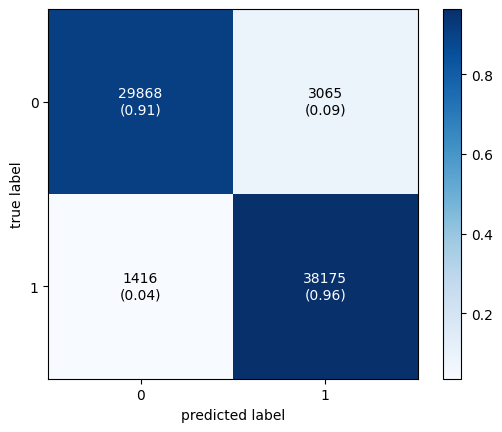

In [31]:
# calculating and plotting the confusion matrix
cm1 = confusion_matrix(yre_test,y_pred_test_rf)
plot_confusion_matrix(conf_mat=cm1,show_absolute=True,
                                show_normed=True,
                                colorbar=True)
plt.show()

In [32]:
xgb= XGBClassifier(max_depth=20)
xgb.fit(xre_train,yre_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [33]:
y_pred_train_xgb = xgb.predict(xre_train)
acc_train_xgb = accuracy_score(yre_train, y_pred_train_xgb)

y_pred_test_xgb = xgb.predict(xre_test)
acc_test_xgb = accuracy_score(yre_test, y_pred_test_xgb)
print(acc_train_xgb)
print(acc_test_xgb)

0.999940906028767
0.9714990899564282


In [34]:
print('Precision: %.3f' % precision_score(yre_test, y_pred_test_xgb,average="micro"))
print('Recall: %.3f' % recall_score(yre_test, y_pred_test_xgb,average="micro"))
print('F-measure: %.3f' % f1_score(yre_test, y_pred_test_xgb,average="micro"))

Precision: 0.971
Recall: 0.971
F-measure: 0.971


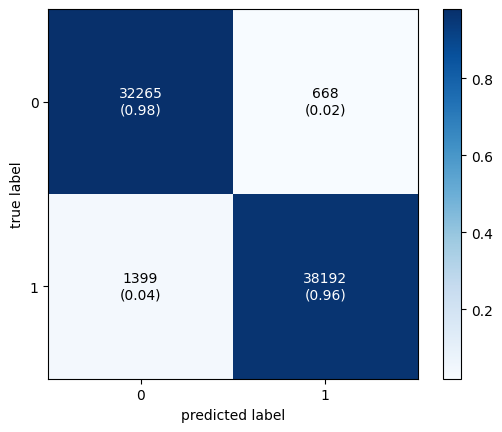

In [35]:
# calculating and plotting the confusion matrix
cm1 = confusion_matrix(yre_test,y_pred_test_xgb)
plot_confusion_matrix(conf_mat=cm1,show_absolute=True,
                                show_normed=True,
                                colorbar=True)
plt.show()

In [36]:
lgbm = LGBMClassifier(max_depth=20)
lgbm.fit(xre_train,yre_train)

[LightGBM] [Info] Number of positive: 91816, number of negative: 77406
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.058453 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2813
[LightGBM] [Info] Number of data points in the train set: 169222, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.542577 -> initscore=0.170722
[LightGBM] [Info] Start training from score 0.170722


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,20
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [37]:
y_pred_train_lgbm = lgbm.predict(xre_train)
acc_train_lgbm = accuracy_score(yre_train, y_pred_train_lgbm)

y_pred_test_lgbm = lgbm.predict(xre_test)
acc_test_lgbm = accuracy_score(yre_test, y_pred_test_lgbm)
print(acc_train_lgbm)
print(acc_test_lgbm)

0.9660682417179799
0.9639016049859357


In [38]:
print('Precision: %.3f' % precision_score(yre_test, y_pred_test_lgbm,average="micro"))
print('Recall: %.3f' % recall_score(yre_test, y_pred_test_lgbm,average="micro"))
print('F-measure: %.3f' % f1_score(yre_test, y_pred_test_lgbm,average="micro"))

Precision: 0.964
Recall: 0.964
F-measure: 0.964


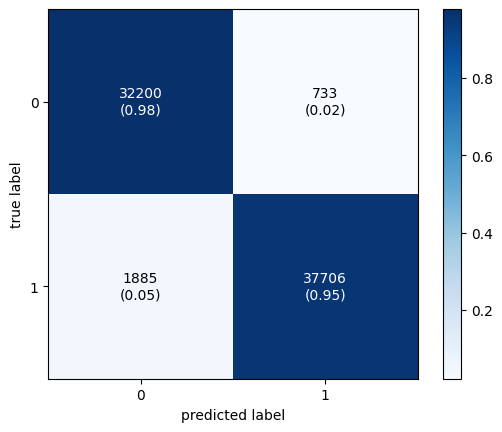

In [39]:
# calculating and plotting the confusion matrix
cm1 = confusion_matrix(yre_test, y_pred_test_lgbm)
plot_confusion_matrix(conf_mat=cm1, show_absolute=True,
                      show_normed=True,
                      colorbar=True)
plt.show()

In [40]:
import json

results = {
    "Random Forest": {
        "train_accuracy": acc_train_rf,
        "test_accuracy": acc_test_rf,
        "precision": precision_score(yre_test, y_pred_test_rf),
        "recall": recall_score(yre_test, y_pred_test_rf),
        "f1": f1_score(yre_test, y_pred_test_rf)
    },
    "LightGBM": {
        "train_accuracy": acc_train_lgbm,
        "test_accuracy": acc_test_lgbm,
        "precision": precision_score(yre_test, y_pred_test_lgbm),
        "recall": recall_score(yre_test, y_pred_test_lgbm),
        "f1": f1_score(yre_test, y_pred_test_lgbm)
    },
    "XGBoost": {
        "train_accuracy": acc_train_xgb,
        "test_accuracy": acc_test_xgb,
        "precision": precision_score(yre_test, y_pred_test_xgb),
        "recall": recall_score(yre_test, y_pred_test_xgb),
        "f1": f1_score(yre_test, y_pred_test_xgb)
    }
}

with open("metrics.json", "w") as f:
    json.dump(results, f)

In [41]:
df_results = pd.DataFrame(results).T
print(df_results)

               train_accuracy  test_accuracy  precision    recall        f1
Random Forest        0.949599       0.938214   0.925679  0.964234  0.944563
LightGBM             0.966068       0.963902   0.980931  0.952388  0.966449
XGBoost              0.999941       0.971499   0.982810  0.964664  0.973652


In [42]:
pipeline_lgbm = Pipeline([
    ('scaler', StandardScaler()),
    ('smoteenn', SMOTEENN()),
    ('model', LGBMClassifier(max_depth=20))
])

pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('smoteenn', SMOTEENN()),
    ('model', XGBClassifier(max_depth=20))
])

pipeline_rf = Pipeline([
    ('scaler', StandardScaler()), 
    ('smoteenn', SMOTEENN()),       
    ('model', RandomForestClassifier(n_estimators=100, max_depth=16, max_features=16))
])


In [43]:
pipeline_rf.fit(xre_train, yre_train)
pipeline_lgbm.fit(xre_train, yre_train)
pipeline_xgb.fit(xre_train, yre_train)

[LightGBM] [Info] Number of positive: 91180, number of negative: 84245
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.053815 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2981
[LightGBM] [Info] Number of data points in the train set: 175425, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.519766 -> initscore=0.079106
[LightGBM] [Info] Start training from score 0.079106


,steps,"[('scaler', ...), ('smoteenn', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,sampling_strategy,'auto'
,random_state,None
,smote,None
,enn,None


In [44]:
import joblib

joblib.dump(pipeline_rf, "models/pipeline_rf.pkl")
joblib.dump(pipeline_lgbm, "models/pipeline_lgbm.pkl")
joblib.dump(pipeline_xgb, "models/pipeline_xgb.pkl")

print("Todos os pipelines foram salvos com sucesso!")

Todos os pipelines foram salvos com sucesso!
